## CausalML 

In [15]:

import os
from pathlib import Path

req = Path("requirements.txt")
if req.exists():
    print("Installing from requirements.txt...")
    # !pip install -r requirements.txt
else:
    print("requirements.txt not found; skipping.")


!pip install causalml dowhy econml


requirements.txt not found; skipping.


### Meta‑Learners

In [16]:
import numpy as np

from causalml.dataset.regression import synthetic_data
from causalml.inference.meta import LRSRegressor, XGBTRegressor

# Generate synthetic data (as in the example notebook)
y, X, treatment, tau, b, e = synthetic_data(mode=1, n=10000, p=8, sigma=1.0)

print("True ATE (synthetic):", np.mean(tau))

# Ready-to-use S-learner (Linear Regression)
learner_s = LRSRegressor()
ate_s = learner_s.estimate_ate(X=X, treatment=treatment, y=y)
print("ATE (LRSRegressor):", ate_s)

# Ready-to-use T-learner (XGBoost)
learner_t = XGBTRegressor(random_state=42)
ate_t = learner_t.estimate_ate(X=X, treatment=treatment, y=y)
print("ATE (XGBTRegressor):", ate_t)


True ATE (synthetic): 0.5027279784032916
ATE (LRSRegressor): (array([0.69520771]), array([0.64709927]), array([0.74331615]))
ATE (XGBTRegressor): (array([0.53954799]), array([0.51588174]), array([0.56321424]))


### ITE/CATE Distribution 

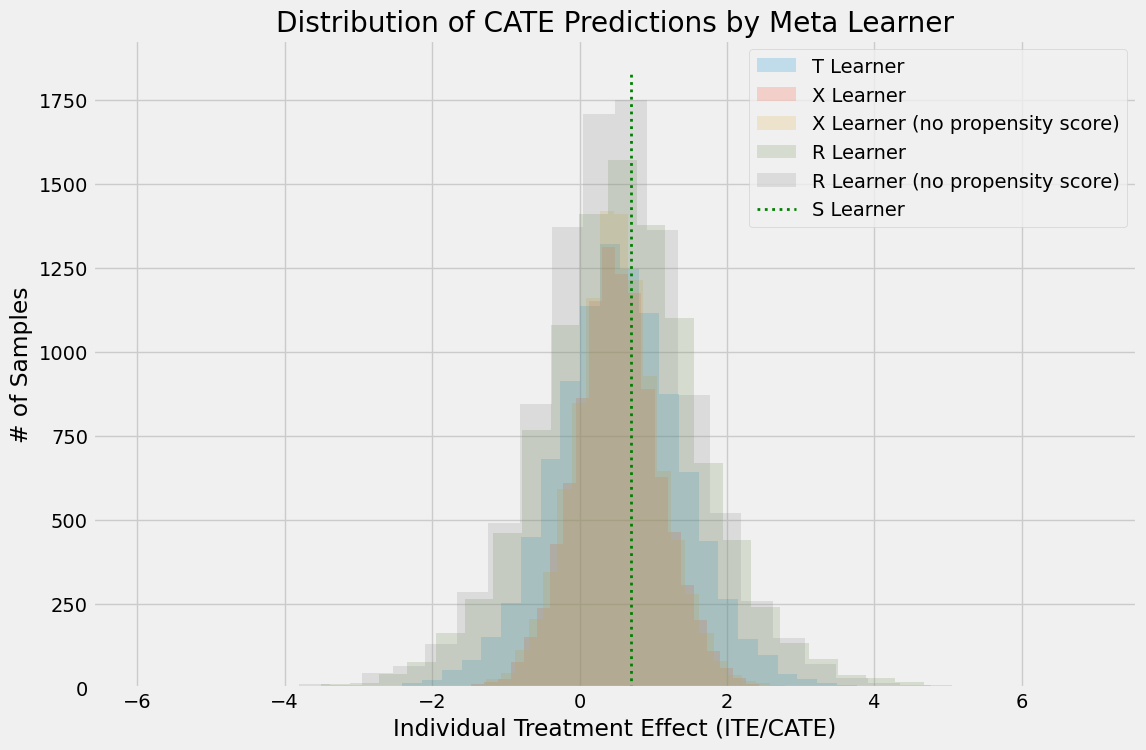

In [17]:
from causalml.inference.meta import BaseSRegressor, BaseTRegressor, BaseXRegressor, BaseRRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Propensity scores (use the true e from synthetic data when available)
# e is returned by synthetic_data above

# S-learner
learner_s = LRSRegressor()
cate_s = learner_s.fit_predict(X=X, treatment=treatment, y=y)

# T-learner
learner_t = BaseTRegressor(learner=XGBRegressor())
cate_t = learner_t.fit_predict(X=X, treatment=treatment, y=y)

# X-learner with propensity score
learner_x = BaseXRegressor(learner=XGBRegressor())
cate_x = learner_x.fit_predict(X=X, treatment=treatment, y=y, p=e)

# X-learner without propensity score
learner_x_no_p = BaseXRegressor(learner=XGBRegressor())
cate_x_no_p = learner_x_no_p.fit_predict(X=X, treatment=treatment, y=y)

# R-learner with propensity score
learner_r = BaseRRegressor(learner=XGBRegressor())
cate_r = learner_r.fit_predict(X=X, treatment=treatment, y=y, p=e)

# R-learner without propensity score
learner_r_no_p = BaseRRegressor(learner=XGBRegressor())
cate_r_no_p = learner_r_no_p.fit_predict(X=X, treatment=treatment, y=y)

alpha = 0.2
bins = 30
plt.figure(figsize=(12, 8))
plt.hist(cate_t, alpha=alpha, bins=bins, label='T Learner')
plt.hist(cate_x, alpha=alpha, bins=bins, label='X Learner')
plt.hist(cate_x_no_p, alpha=alpha, bins=bins, label='X Learner (no propensity score)')
plt.hist(cate_r, alpha=alpha, bins=bins, label='R Learner')
plt.hist(cate_r_no_p, alpha=alpha, bins=bins, label='R Learner (no propensity score)')
plt.vlines(cate_s[0], 0, plt.gca().get_ylim()[1], label='S Learner',
           linestyles='dotted', colors='green', linewidth=2)
plt.title('Distribution of CATE Predictions by Meta Learner')
plt.xlabel('Individual Treatment Effect (ITE/CATE)')
plt.ylabel('# of Samples')
plt.legend()
plt.show()


### Validating Meta‑Learner Accuracy 

In [18]:
from causalml.dataset.regression import simulate_nuisance_and_easy_treatment
from causalml.dataset import get_synthetic_summary_holdout

# Summary table over multiple simulations (synthetic benchmark)
train_summary, validation_summary = get_synthetic_summary_holdout(
    simulate_nuisance_and_easy_treatment,
    n=10000,
    valid_size=0.2,
    k=10
)

train_summary


,Abs % Error of ATE,MSE,KL Divergence
Actuals,0.000000,0.000000,0.000000
S Learner (LR),0.385175,0.080039,3.785922
S Learner (XGB),0.070326,0.107572,0.271394
T Learner (LR),0.362125,0.037382,0.327810
T Learner (XGB),0.066660,0.723855,1.098020
X Learner (LR),0.362125,0.037382,0.327810
X Learner (XGB),0.055606,0.338224,0.688775
R Learner (LR),0.257602,0.031165,0.270192
R Learner (XGB),0.096417,1.077130,1.257004


In [19]:
validation_summary

,Abs % Error of ATE,MSE,KL Divergence
Actuals,0.000000,0.000000,0.000000
S Learner (LR),0.391542,0.081028,3.834142
S Learner (XGB),0.074043,0.102398,0.283851
T Learner (LR),0.365336,0.037658,0.359391
T Learner (XGB),0.079898,0.461297,0.904727
X Learner (LR),0.365336,0.037658,0.359391
X Learner (XGB),0.065005,0.250201,0.572703
R Learner (LR),0.258401,0.030957,0.293928
R Learner (XGB),0.116775,0.709990,1.066961


### Feature Importance + SHAP 

get_importance not available: X, tau, and classes must be provided.


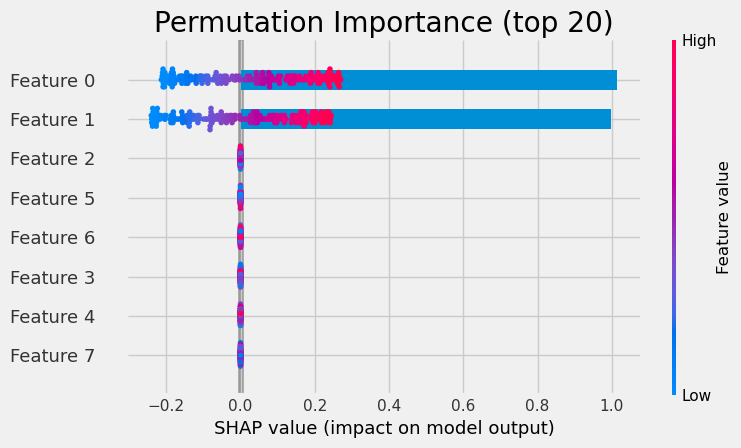

In [20]:
import shap
from causalml.inference.meta import BaseSRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Use synthetic data for interpretation to align with example
model_s = BaseSRegressor(learner=RandomForestRegressor(random_state=42))
model_s.fit(X=X, treatment=treatment, y=y)

# Built-in importance (if available in your CausalML version)
try:
    imp = model_s.get_importance()
    imp.plot(kind='barh', figsize=(8, 6), title='Feature Importance (CausalML)')
except Exception as e:
    print('get_importance not available:', e)

# Permutation importance
X_train, X_test, y_train, y_test = train_test_split(X, tau, test_size=0.3, random_state=42)
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
perm = permutation_importance(rf, X_test, y_test, random_state=42)

import pandas as pd
perm_series = pd.Series(perm.importances_mean).sort_values()
perm_series.tail(20).plot(kind='barh', figsize=(8, 6), title='Permutation Importance (top 20)')

# SHAP values (optional; may take time)
try:
    explainer = shap.Explainer(rf, X_train)
    shap_values = explainer(X_test[:200])
    shap.summary_plot(shap_values, X_test[:200], show=True)
except Exception as e:
    print('SHAP not available or failed:', e)


### CausalML on Energy Dataset 

**Target (outcome):** `Value_co2_emissions_kt_by_country`

**Treatment:** `Renewable energy share in the total final energy consumption (%)` (binarized at median)

**Controls:** macro/energy/geo features

In [21]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("global-data-on-sustainable-energy.csv")
energy_ci = pd.read_csv(DATA_PATH)

outcome_col = "Value_co2_emissions_kt_by_country"
treatment_raw_col = "Renewable energy share in the total final energy consumption (%)"

# Handle slight column-name variations for density
_density_cols = [c for c in energy_ci.columns if "Density" in c]
if not _density_cols:
    raise KeyError("No column containing 'Density' found in dataset")
density_col = _density_cols[0]

control_cols = [
    "Entity",
    "Year",
    "gdp_per_capita",
    "gdp_growth",
    "Primary energy consumption per capita (kWh/person)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)",
    "Access to electricity (% of population)",
    "Access to clean fuels for cooking",
    "Electricity from fossil fuels (TWh)",
    "Electricity from nuclear (TWh)",
    "Electricity from renewables (TWh)",
    "Low-carbon electricity (% electricity)",
    "Renewable-electricity-generating-capacity-per-capita",
    "Renewables (% equivalent primary energy)",
    "Financial flows to developing countries (US $)",
    density_col,
    "Land Area(Km2)",
    "Latitude",
    "Longitude",
]

# Keep only relevant columns and drop missing treatment/outcome
df_ci = energy_ci[[outcome_col, treatment_raw_col] + control_cols].copy()

# Clean numeric columns that may contain commas as thousands separators
for col in [outcome_col, treatment_raw_col] + control_cols:
    if col == "Entity":
        continue
    df_ci[col] = (
        df_ci[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", pd.NA)
    )
    df_ci[col] = pd.to_numeric(df_ci[col], errors="coerce")
df_ci = df_ci.dropna(subset=[outcome_col, treatment_raw_col])

# Binary treatment (high vs low renewable share)
df_ci["treatment"] = (
    df_ci[treatment_raw_col] >= df_ci[treatment_raw_col].median()
).astype(int)

X = df_ci[control_cols]
y = df_ci[outcome_col].values
t = df_ci["treatment"].values


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

cat_cols = ["Entity"]
num_cols = [c for c in control_cols if c not in cat_cols]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Ensure numeric cols are truly numeric (strip commas, coerce)
for col in num_cols:
    X[col] = (
        X[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", pd.NA)
    )
    X[col] = pd.to_numeric(X[col], errors="coerce")
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

X_prepared = preprocess.fit_transform(X)
feature_names = list(preprocess.get_feature_names_out())

# Some models work better with dense arrays
X_dense = X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared


### Meta‑Learners on Energy Data (LRSRegressor + XGBTRegressor)

In [23]:
from causalml.inference.meta import LRSRegressor, XGBTRegressor

np.random.seed(42)

# S-learner (Linear Regression)
lr_learner = LRSRegressor()
ate_lr = lr_learner.estimate_ate(X=X_dense, treatment=t, y=y)
lr_learner.fit(X_dense, t, y)
tau_lr = lr_learner.predict(X_dense)

# T-learner (XGBoost)
xgb_learner = XGBTRegressor(random_state=42)
ate_xgb = xgb_learner.estimate_ate(X=X_dense, treatment=t, y=y)
xgb_learner.fit(X_dense, t, y)
tau_xgb = xgb_learner.predict(X_dense)

print("ATE (LRSRegressor):", ate_lr)
print("ATE (XGBTRegressor):", ate_xgb)


ATE (LRSRegressor): (array([-21045.46165828]), array([-33027.54496823]), array([-9063.37834833]))
ATE (XGBTRegressor): (array([-47904.94645848]), array([-64681.13753353]), array([-31128.75538344]))


### Feature Importance

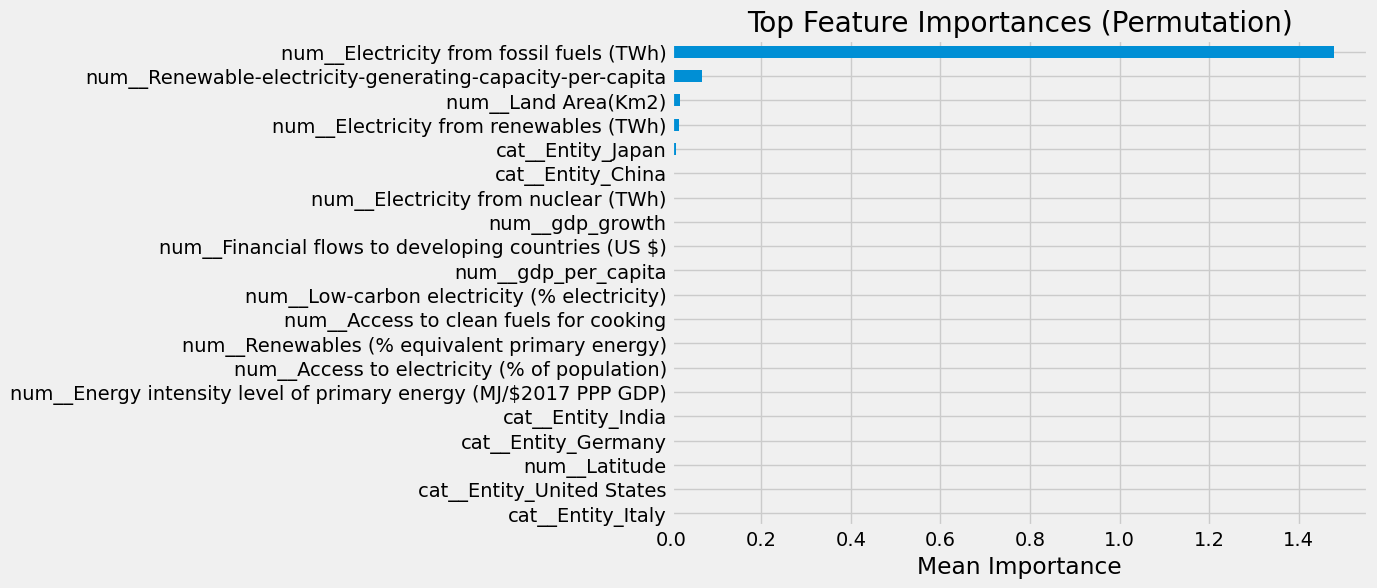

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Use tau from XGBTRegressor and compute permutation importance (as in the example)
X_train, X_test, y_train, y_test = train_test_split(
    X_dense, tau_xgb, test_size=0.3, random_state=42
)

model_tau = RandomForestRegressor(random_state=42)
model_tau.fit(X_train, y_train)

perm = permutation_importance(
    estimator=model_tau,
    X=X_test,
    y=y_test,
    random_state=42
)

imp = pd.Series(perm.importances_mean, index=feature_names).sort_values()
ax = imp.tail(20).plot(kind="barh", figsize=(8, 6))
ax.set_title("Top Feature Importances (Permutation)")
ax.set_xlabel("Mean Importance")
plt.show()


### Analysis (CausalML)

- **Hypothesis**: Higher renewable energy share reduces CO2 emissions.
- **Energy dataset ATE (LRSRegressor)**: `-21,045.46` kt (95% CI: `-33,027.54` to `-9,063.38`).
- **Energy dataset ATE (XGBTRegressor)**: `-47,904.95` kt (95% CI: `-64,681.14` to `-31,128.76`).
- **Interpretation**: Both learners estimate a negative treatment effect, so the results support the hypothesis that higher renewable share is associated with lower CO2 emissions after controlling for observed covariates.
- **Model comparison**: XGBTRegressor gives a larger magnitude than LRSRegressor, suggesting non-linear patterns in the treatment effect.
- **Feature importance**: Use the real-data feature-importance plot to report the top drivers and connect them to the effect interpretation.



## DoWhy (Common Causes + Instruments)

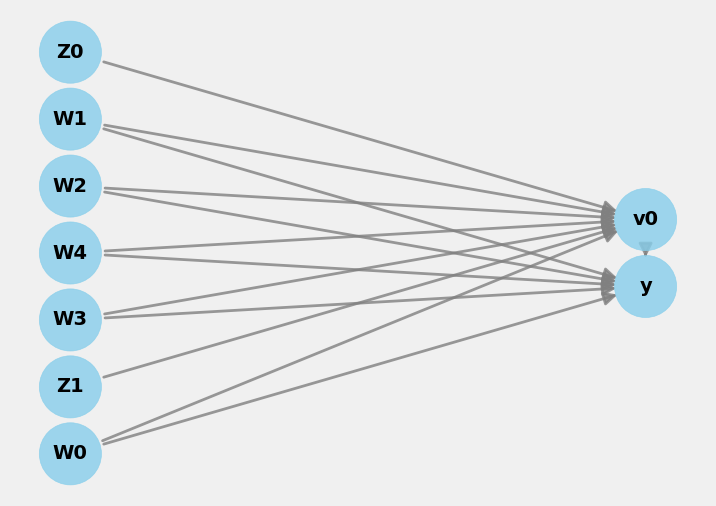

In [29]:
from dowhy import CausalModel
from dowhy.datasets import linear_dataset
import numpy as np
np.random.seed(42)

data = linear_dataset(
    beta=10,
    num_common_causes=5,
    num_instruments=2,
    num_effect_modifiers=1,
    num_samples=1000,
    treatment_is_binary=True,
    outcome_is_binary=False,
)

df_dw = data["df"]
treatment_name = data["treatment_name"]
outcome_name = data["outcome_name"]
common_causes = data["common_causes_names"]
instruments = data["instrument_names"]

model = CausalModel(
    data=df_dw,
    treatment=treatment_name,
    outcome=outcome_name,
    common_causes=common_causes,
    instruments=instruments,
)

model.view_model()


In [30]:
identified_estimand = model.identify_effect()
print(identified_estimand)

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print(estimate)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W0,W3,W4,W2,W1])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W3,W4,W2,W1,U) = P(y|v0,W0,W3,W4,W2,W1)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                              -1⎤
 ⎢    d        ⎛    d          ⎞  ⎥
E⎢─────────(y)⋅⎜─────────([v₀])⎟  ⎥
 ⎣d[Z₀  Z₁]    ⎝d[Z₀  Z₁]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0,Z1})
Estimand assumption 2, Exclusion: If we remove {Z0,Z1}→{v0}, then ¬({Z0,Z1}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d                       
─────(E[y|W0,W3,W4,W2,W1])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W3,W4,W2,W1,U) = P(y|v0,W0,W3,W4,W2,W1)

*** Causal E

In [31]:

refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)
print(refute)


Refute: Add a random common cause
Estimated effect:9.972453900433738
New effect:9.972255559784436
p value:0.96



### DoWhy On Real Dataset (`df_ci`)


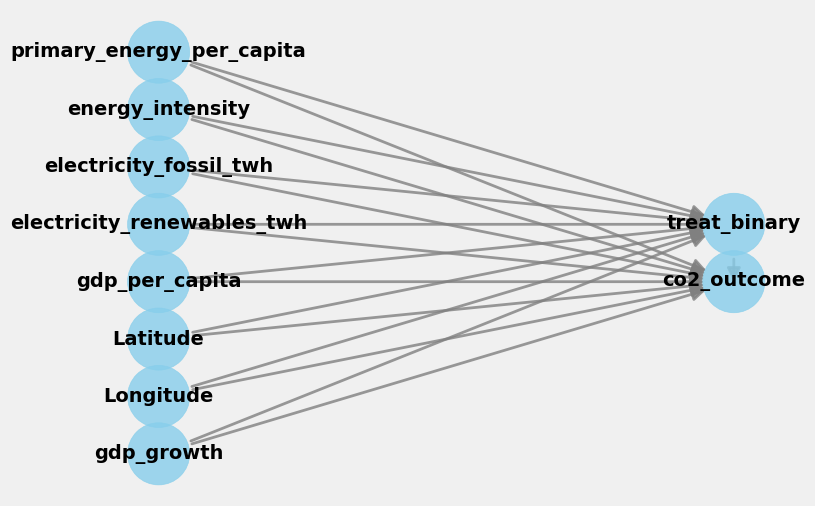

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
───────────────(E[co_2_outcome|gdp_growth,energy_intensity,Latitude,gdp_per_ca ↪
d[treat_binary]                                                                ↪

↪                                                                              ↪
↪ pita,electricity_renewables_twh,electricity_fossil_twh,Longitude,primary_ene ↪
↪                                                                              ↪

↪                 
↪ rgy_per_capita])
↪                 
Estimand assumption 1, Unconfoundedness: If U→{treat_binary} and U→co2_outcome then P(co2_outcome|treat_binary,gdp_growth,energy_intensity,Latitude,gdp_per_capita,electricity_renewables_twh,electricity_fossil_twh,Longitude,primary_energy_per_capita,U) = P(co2_outcome|treat_binary,gdp_growth,energy_intensity,Latitude,gdp_per_capita,electricity_r

In [32]:
# Build a DoWhy-ready real-data frame from df_ci
real_common_causes_raw = [
    'gdp_per_capita',
    'gdp_growth',
    'Primary energy consumption per capita (kWh/person)',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
    'Electricity from fossil fuels (TWh)',
    'Electricity from renewables (TWh)',
    'Latitude',
    'Longitude',
]

df_dowhy_real = df_ci[['treatment', outcome_col] + real_common_causes_raw].dropna().copy()
rename_map = {
    outcome_col: 'co2_outcome',
    'treatment': 'treat_binary',
    'Primary energy consumption per capita (kWh/person)': 'primary_energy_per_capita',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)': 'energy_intensity',
    'Electricity from fossil fuels (TWh)': 'electricity_fossil_twh',
    'Electricity from renewables (TWh)': 'electricity_renewables_twh',
}
df_dowhy_real = df_dowhy_real.rename(columns=rename_map)

real_common_causes = [
    'gdp_per_capita',
    'gdp_growth',
    'primary_energy_per_capita',
    'energy_intensity',
    'electricity_fossil_twh',
    'electricity_renewables_twh',
    'Latitude',
    'Longitude',
]

model_real = CausalModel(
    data=df_dowhy_real,
    treatment='treat_binary',
    outcome='co2_outcome',
    common_causes=real_common_causes,
)
model_real.view_model()

identified_real = model_real.identify_effect()
print(identified_real)

estimate_real = model_real.estimate_effect(
    identified_real,
    method_name='backdoor.linear_regression'
)
print(estimate_real)

refute_real = model_real.refute_estimate(
    identified_real,
    estimate_real,
    method_name='random_common_cause'
)
print(refute_real)


## Conclusion

Using CausalML on the real energy dataset, both LRSRegressor and XGBTRegressor estimated negative average treatment effects for high renewable-energy share on CO2 emissions, supporting the hypothesis that higher renewable share is associated with lower emissions after adjustment for observed covariates; XGBTRegressor produced a larger magnitude effect than LRSRegressor, suggesting non-linear treatment-response structure. In DoWhy, the synthetic check remained close to the known data-generating effect (about 9.97 vs beta=10) and was stable under random-common-cause refutation, while the added real-data DoWhy model on `df_ci` estimated a negative backdoor effect (about -7370.80) with minimal refutation shift (about -7367.18, p-value 0.90), which is directionally consistent with the CausalML result but still relies on standard observational assumptions, especially no major unmeasured confounding and the binary treatment design.
